几何分布描述的是在一次次独立的伯努利试验中，发生“首次成功”之前需要进行多少次试验。我们可以将每次伯努利试验理解为一次“掷硬币”实验，每次试验只有两种可能结果：成功或失败，并且每次试验之间相互独立、成功概率均为 $p $。

$$P(X=k) = (1-p)^{k-1} \cdot p, \quad k=1,2,3,\ldots$$

#### 几何分布的累积分布函数（CDF）

几何分布的 CDF 定义为：

$$F(k) = P(X \leq k) = \sum_{i=0}^{k-1} p(1-p)^i = p \cdot \frac{1 - (1-p)^k}{1 - (1-p)} = 1 - (1-p)^k$$

它表示**在前 \( k \) 次试验中至少成功一次**的概率，即首次成功发生在第 \( k \) 次或之前的概率。

为了推导几何分布的数学期望 $E(X) $，即首次成功试验的平均次数，我们有：
$$E(X)=\sum_{k=1}^{\infty}k\cdot P(X=k)=\sum_{k=1}^{\infty}k(1-p)^{k-1}p.$$
利用求和公式，已知：
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}, \quad |x|<1.$$
令 $x=1-p $（满足 $|1-p|<1 $），则：
$$E(X)=p\cdot \frac{1}{p^2}=\frac{1}{p}.$$
这表明如果成功概率为 $p $，则平均需要 $\frac{1}{p} $次试验才会出现第一次成功。

$$P(X>n+m \mid X>n)=P(X>m)$$

矩母函数（MGF）的推导
矩母函数是研究分布其他性质的重要工具。几何分布的矩母函数 $$M_X(t) $$定义为：
$$M_X(t)=E(e^{tX})=\sum_{k=1}^{\infty}e^{tk}P(X=k)=\sum_{k=1}^{\infty}e^{tk}(1-p)^{k-1}p.$$
令 $$u=e^{t}(1-p) $$，则有：
$$M_X(t)=pe^{t}\sum_{k=1}^{\infty} u^{k-1} = pe^{t}\cdot \frac{1}{1-u}, \quad \text{当}\ |u|<1.$$
因此，
$$M_X(t)=\frac{pe^{t}}{1-e^{t}(1-p)}.$$
这个矩母函数对于计算任意矩以及分析分布的其他统计性质非常有用。

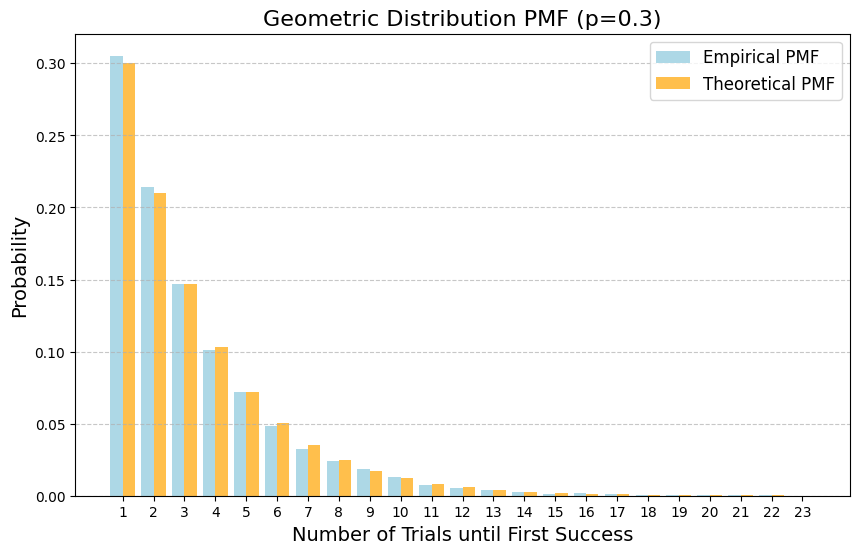

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

np.random.seed(42)

p = 0.3

num_samples = 10000
data = np.random.geometric(p, size=num_samples)

max_trial = data.max()
trials = np.arange(1, max_trial+1)
frequency = np.array([np.sum(data == k) for k in trials])
probability_empirical = frequency / num_samples

probability_theoretical = geom.pmf(trials, p)

plt.figure(figsize=(10, 6))
plt.bar(trials - 0.2, probability_empirical, width=0.4, label='Empirical PMF', color='lightblue')
plt.bar(trials + 0.2, probability_theoretical, width=0.4, label='Theoretical PMF', color='orange', alpha=0.7)
plt.title(f'Geometric Distribution PMF (p={p})', fontsize=16)
plt.xlabel('Number of Trials until First Success', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.xticks(trials)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
empirical_mean = np.mean(data)
empirical_var = np.var(data)
theoretical_mean = 1 / p
theoretical_var = (1 - p) / (p ** 2)

print("Empirical Mean:", empirical_mean)
print("Theoretical Mean:", theoretical_mean)
print("Empirical Variance:", empirical_var)
print("Theoretical Variance:", theoretical_var)

Empirical Mean: 3.2706
Theoretical Mean: 3.3333333333333335
Empirical Variance: 7.38017564
Theoretical Variance: 7.777777777777778


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import geom
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

p_click = 0.1
num_users = 5000

np.random.seed(2023)
num_ad_views = np.random.geometric(p_click, size=num_users)

avg_stay_time = np.random.normal(loc=5, scale=2, size=num_users)

click_threshold = np.percentile(num_ad_views, 40)
labels = (num_ad_views <= click_threshold).astype(int)

data_ml = pd.DataFrame({
    'num_ad_views': num_ad_views,
    'avg_stay_time': avg_stay_time,
    'click': labels
})

# 数据探索
print("数据样本：")
print(data_ml.head())
print("\n特征描述统计：")
print(data_ml.describe())

数据样本：
   num_ad_views  avg_stay_time  click
0             4       4.522608      1
1            21       5.872696      0
2             9       8.571384      0
3             2       5.066967      1
4             2       4.647483      1

特征描述统计：
       num_ad_views  avg_stay_time        click
count   5000.000000    5000.000000  5000.000000
mean       9.913200       5.030926     0.417400
std        9.490652       2.013184     0.493179
min        1.000000      -3.103831     0.000000
25%        3.000000       3.710094     0.000000
50%        7.000000       5.058978     0.000000
75%       13.000000       6.368914     1.000000
max       94.000000      12.128648     1.000000


In [6]:
X = data_ml[['num_ad_views', 'avg_stay_time']]
y = data_ml['click']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 建立逻辑回归模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 进行预测
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n逻辑回归模型的预测准确率：", accuracy)
print("\n分类报告：")
print(classification_report(y_test, y_pred))


逻辑回归模型的预测准确率： 1.0

分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       902
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



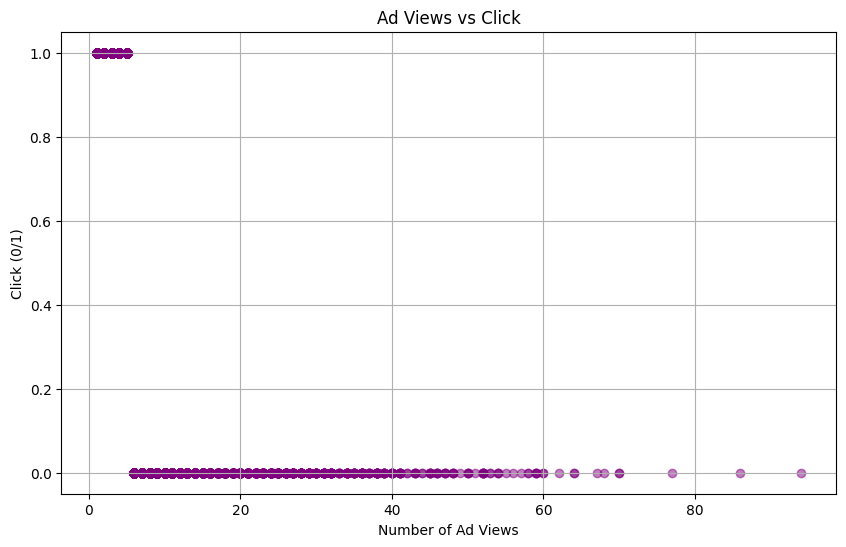

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(data_ml['num_ad_views'], data_ml['click'], alpha=0.5, color='purple')
plt.xlabel('Number of Ad Views')
plt.ylabel('Click (0/1)')
plt.title('Ad Views vs Click')
plt.grid(True)
plt.show()